In [3]:
from google.colab.patches import cv2_imshow
from google.colab import drive
import numpy as np
import cv2
import matplotlib.pyplot as plt
drive.mount('/content/gdrive')

Mounted at /content/gdrive


(2048, 1080, 3)


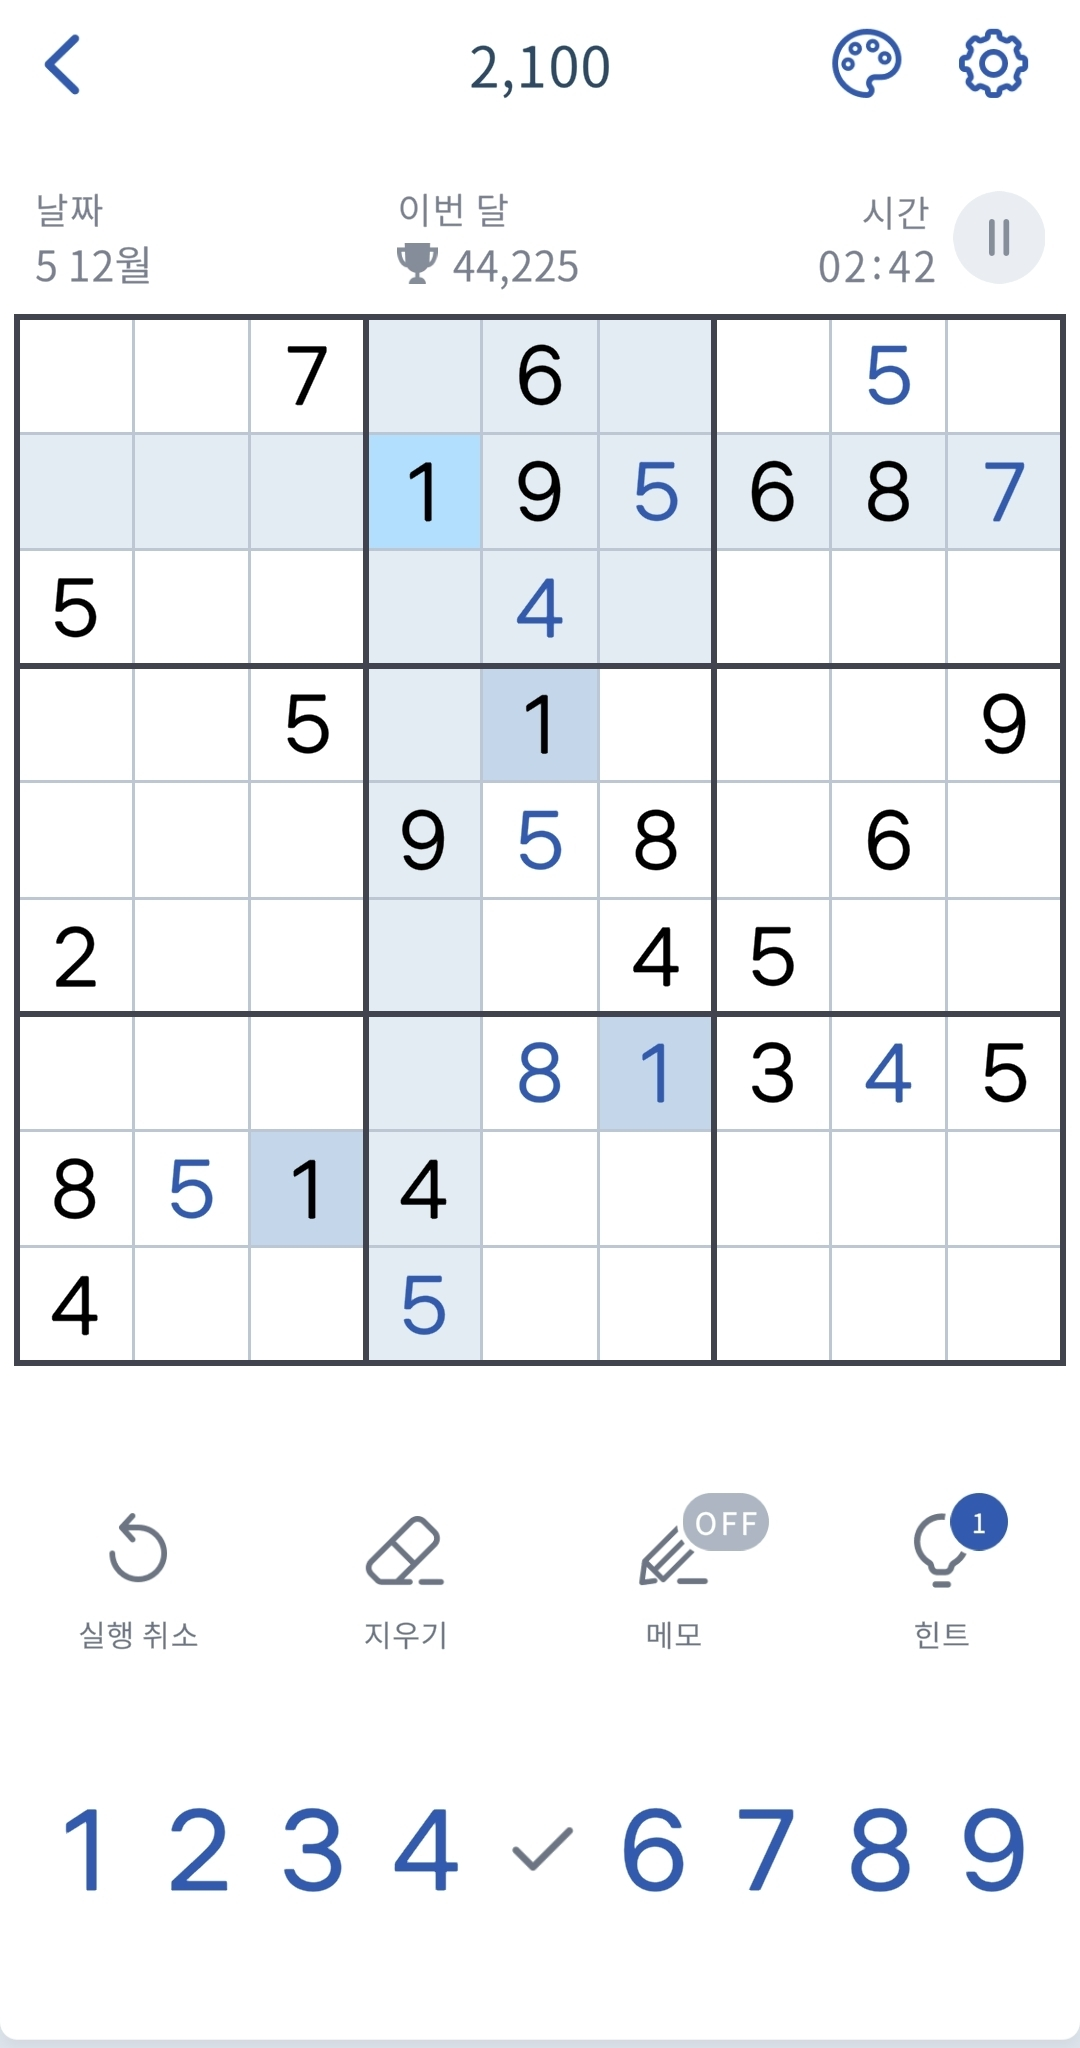

In [40]:
img = cv2.imread('/content/gdrive/My Drive/IP/과제/스도쿠.jpg')
print(img.shape)
#gImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
#plt.imshow(gImg, cmap='gray')
cv2_imshow(img)

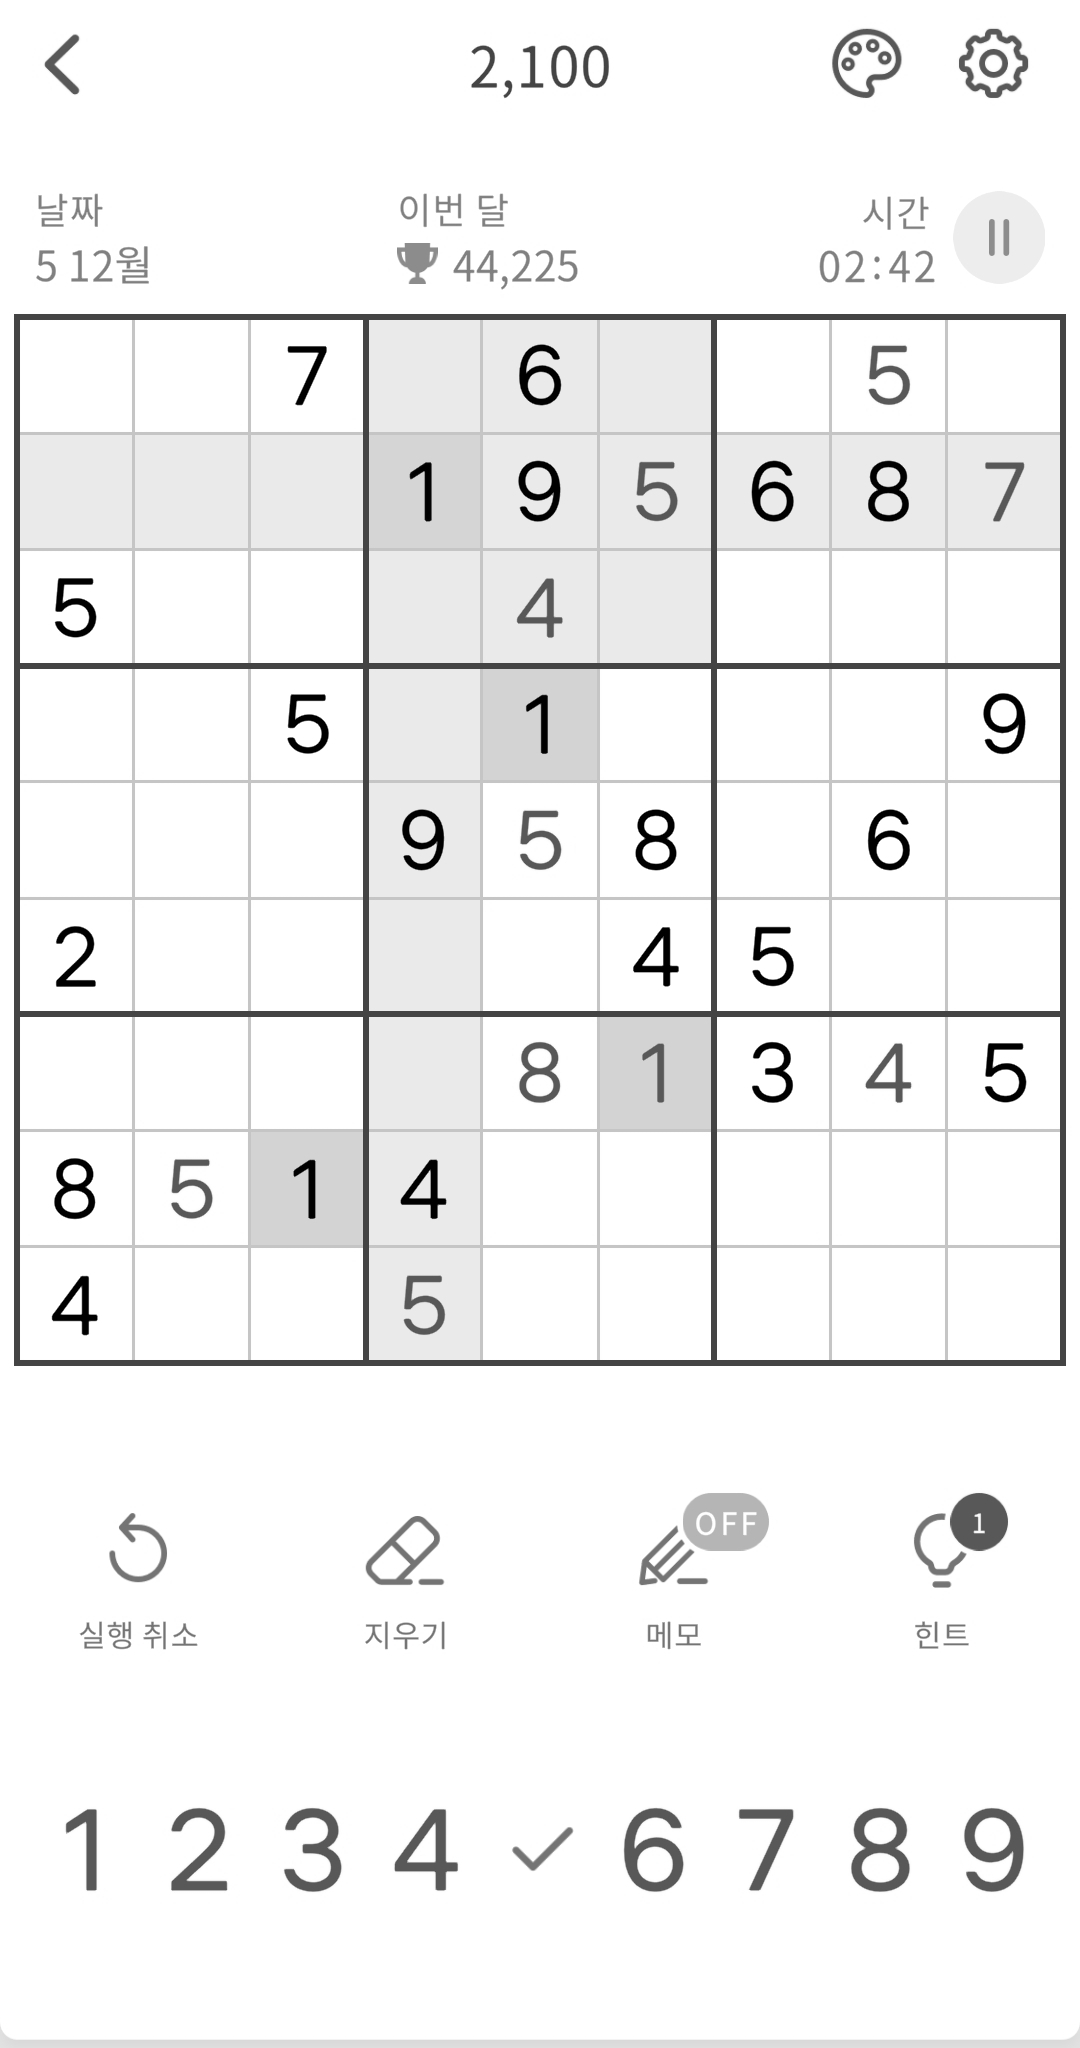

In [189]:
# 이미지 흑백(그레이스케일) 변환
gImg = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 변환된 이미지 출력
cv2_imshow(gImg)

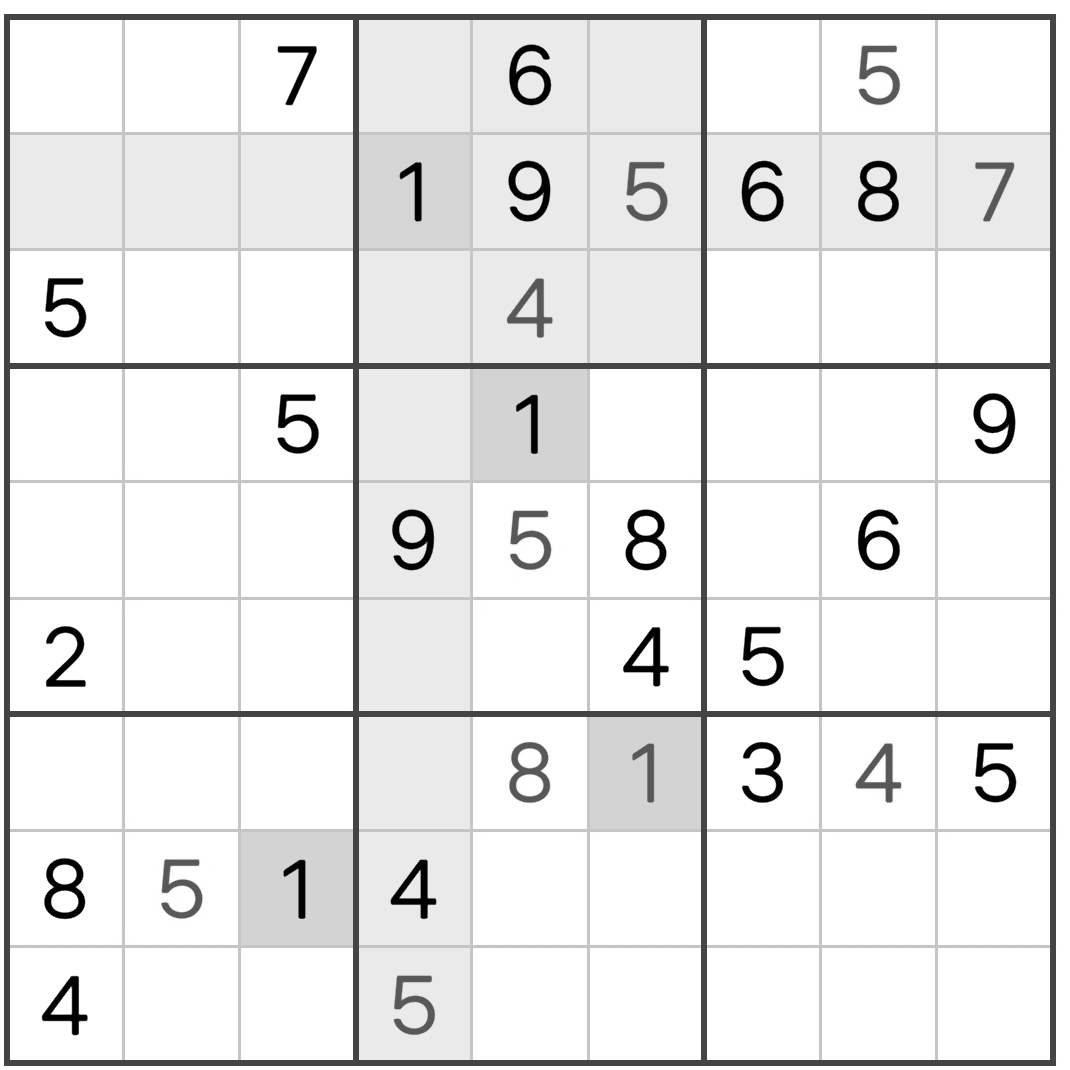

In [190]:
# 자를 영역 좌표 지정 (y: 세로, x: 가로)
y_start, y_end = 300, 1370
x_start, x_end = 10, 1100

# 이미지 자르기
cropped = gImg[y_start:y_end, x_start:x_end]

# 결과 출력
cv2_imshow(cropped)

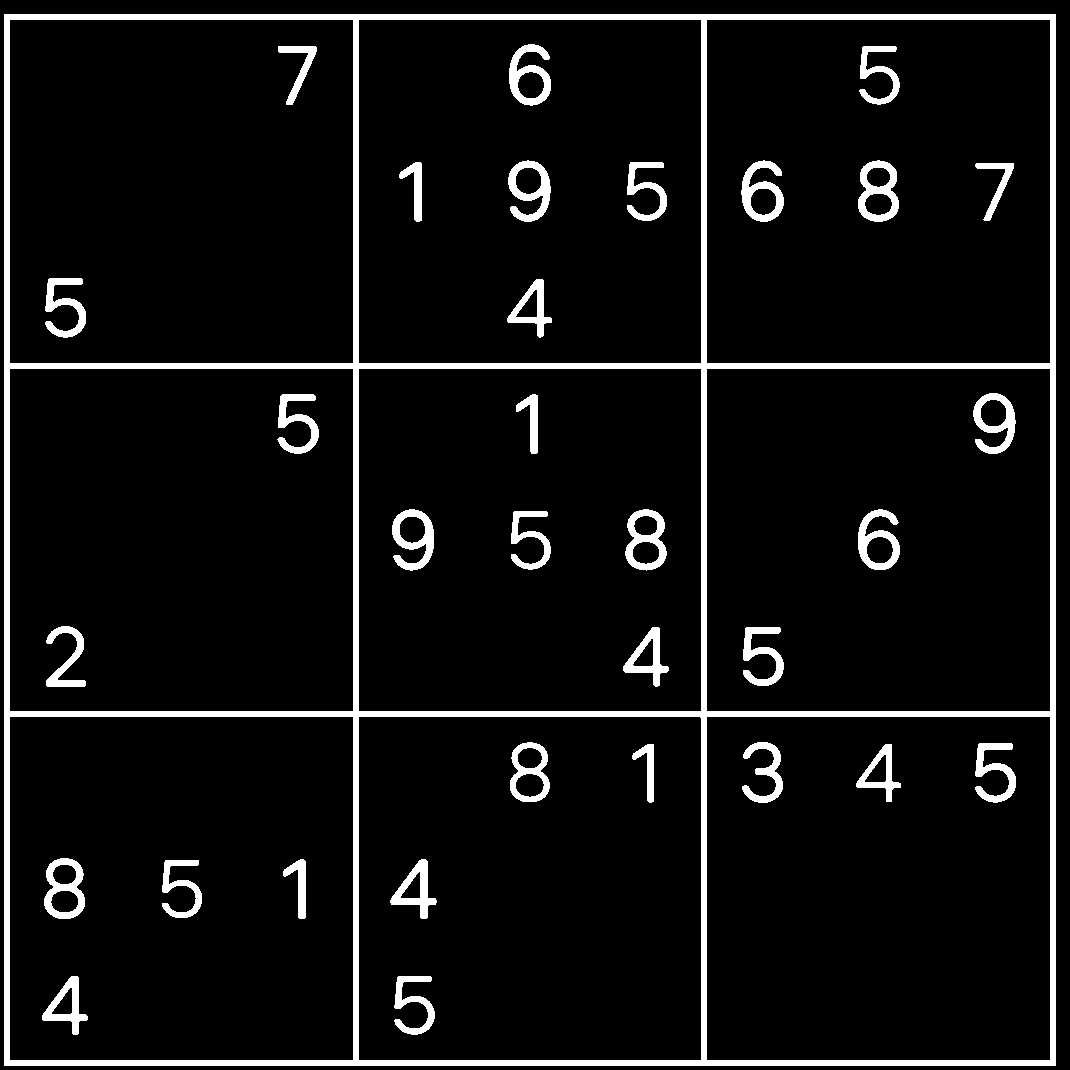

In [191]:
blur = cv2.GaussianBlur(cropped, (3,3), 0)

# Otsu 이진화 (전체 이미지 기준으로 자동 threshold)
_, otsu_bin = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 결과 출력
cv2_imshow(otsu_bin)


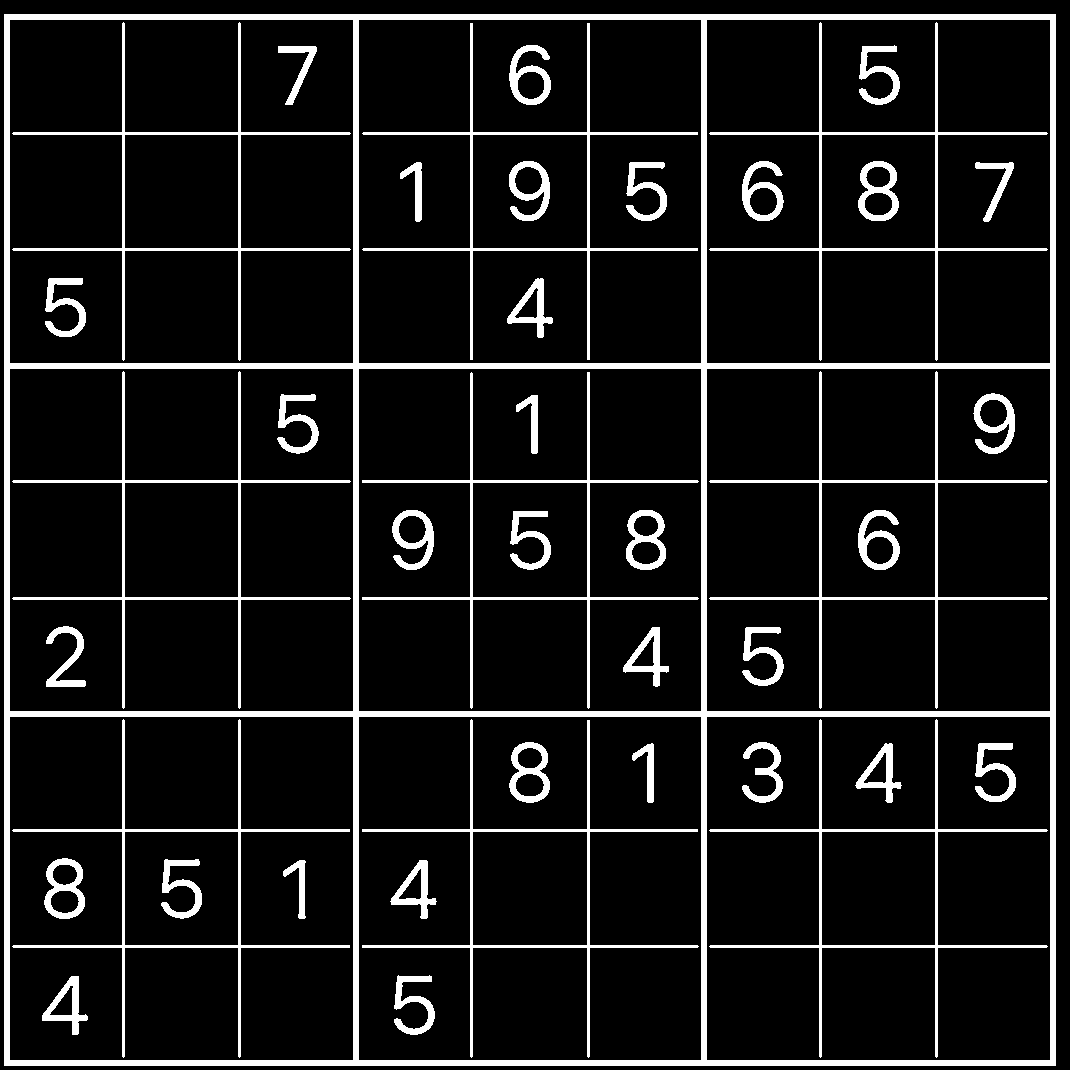

In [192]:
# 적응형 이진화 (지역 대비에 따라 threshold)
adaptive_bin = cv2.adaptiveThreshold(
    blur, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    11, 2
)

cv2_imshow(adaptive_bin)

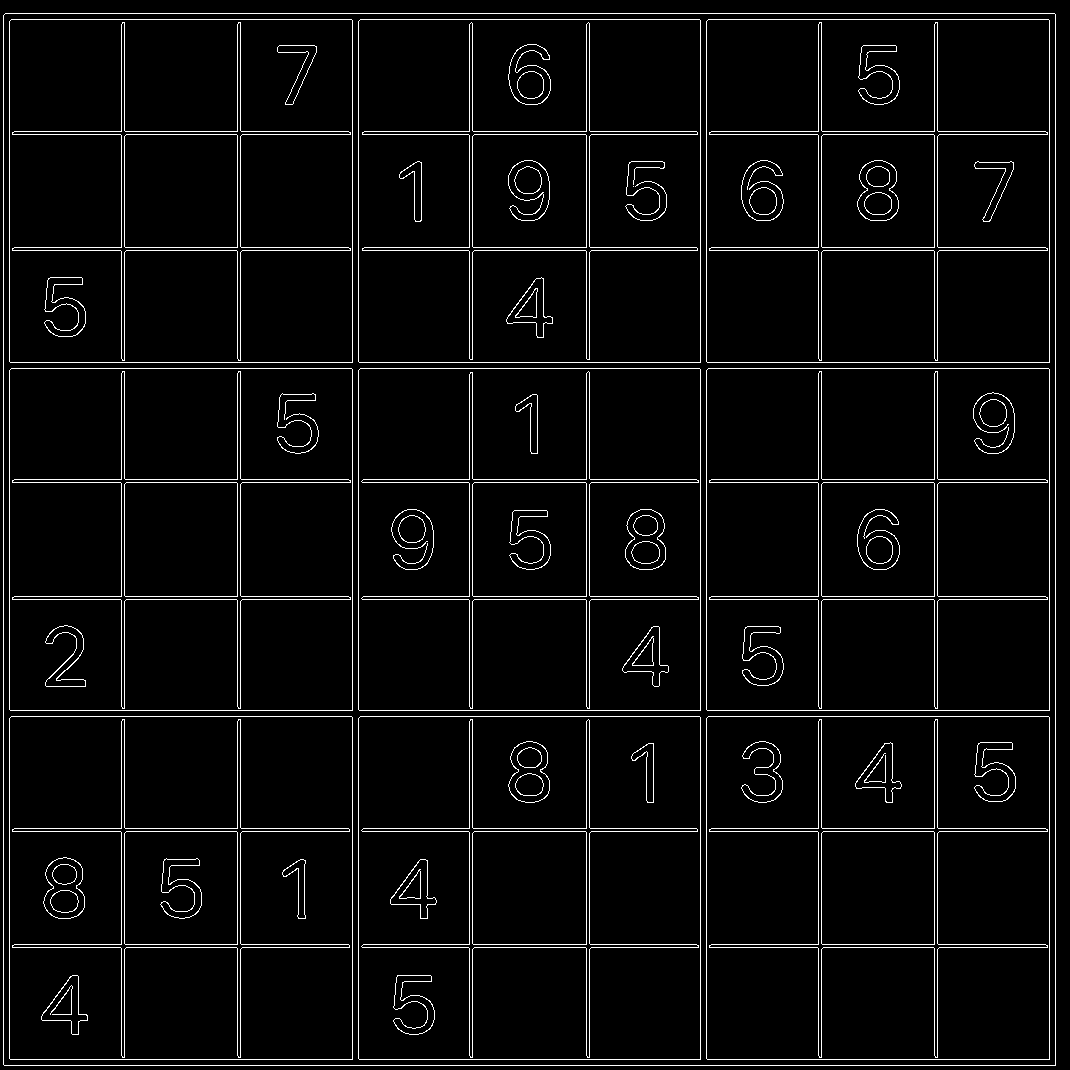

In [193]:
# 에지 검출
edges = cv2.Canny(adaptive_bin, 50, 150, apertureSize=3)

# 결과 출력
cv2_imshow(edges)

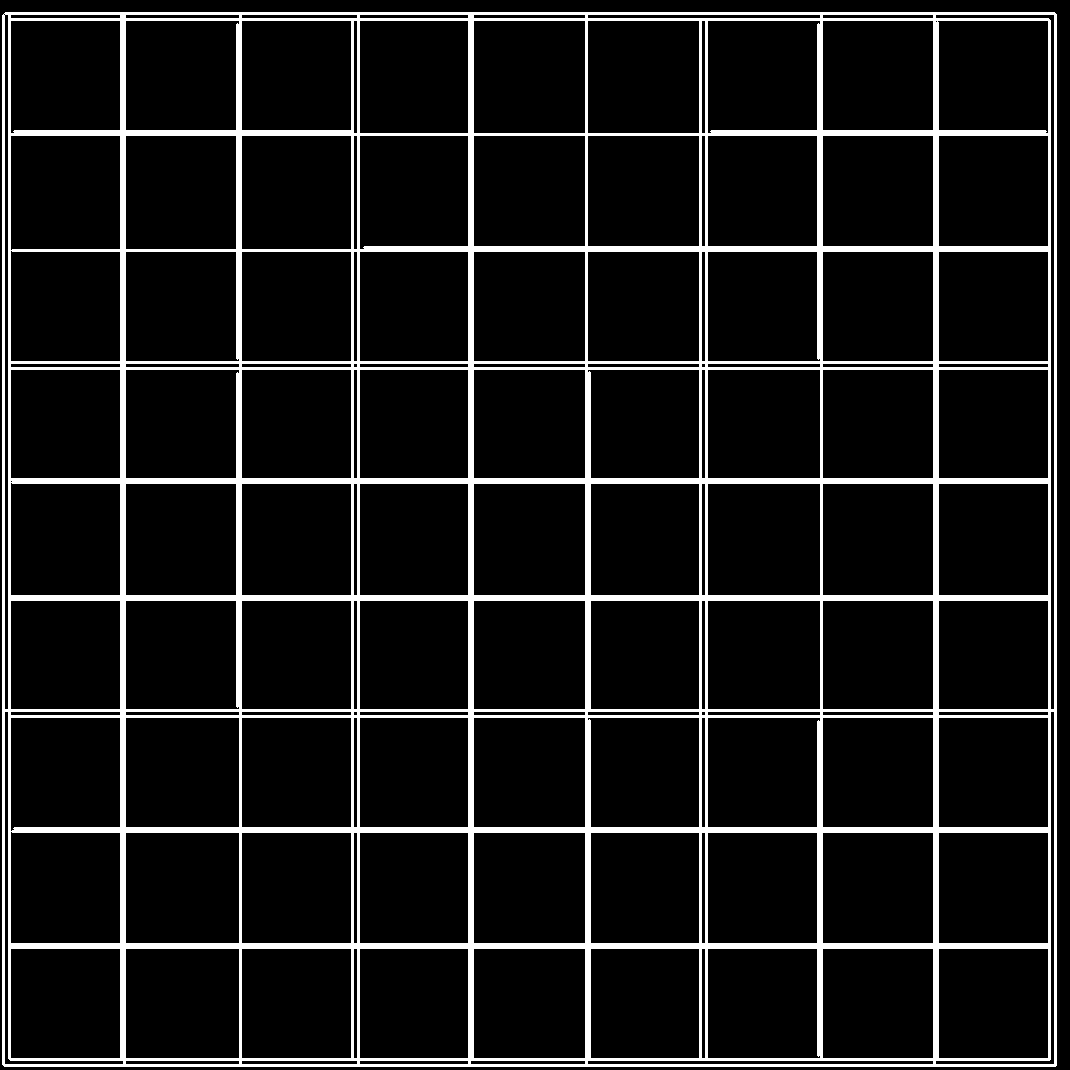

In [194]:
# 허프 변환으로 직선 검출
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100,
                        minLineLength=100, maxLineGap=10)

# 직선만 시각화
line_img = np.zeros_like(cropped)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(line_img, (x1,y1), (x2,y2), 255, 2)       # 흑백 캔버스에 흰색 직선

# 결과 출력
cv2_imshow(line_img)

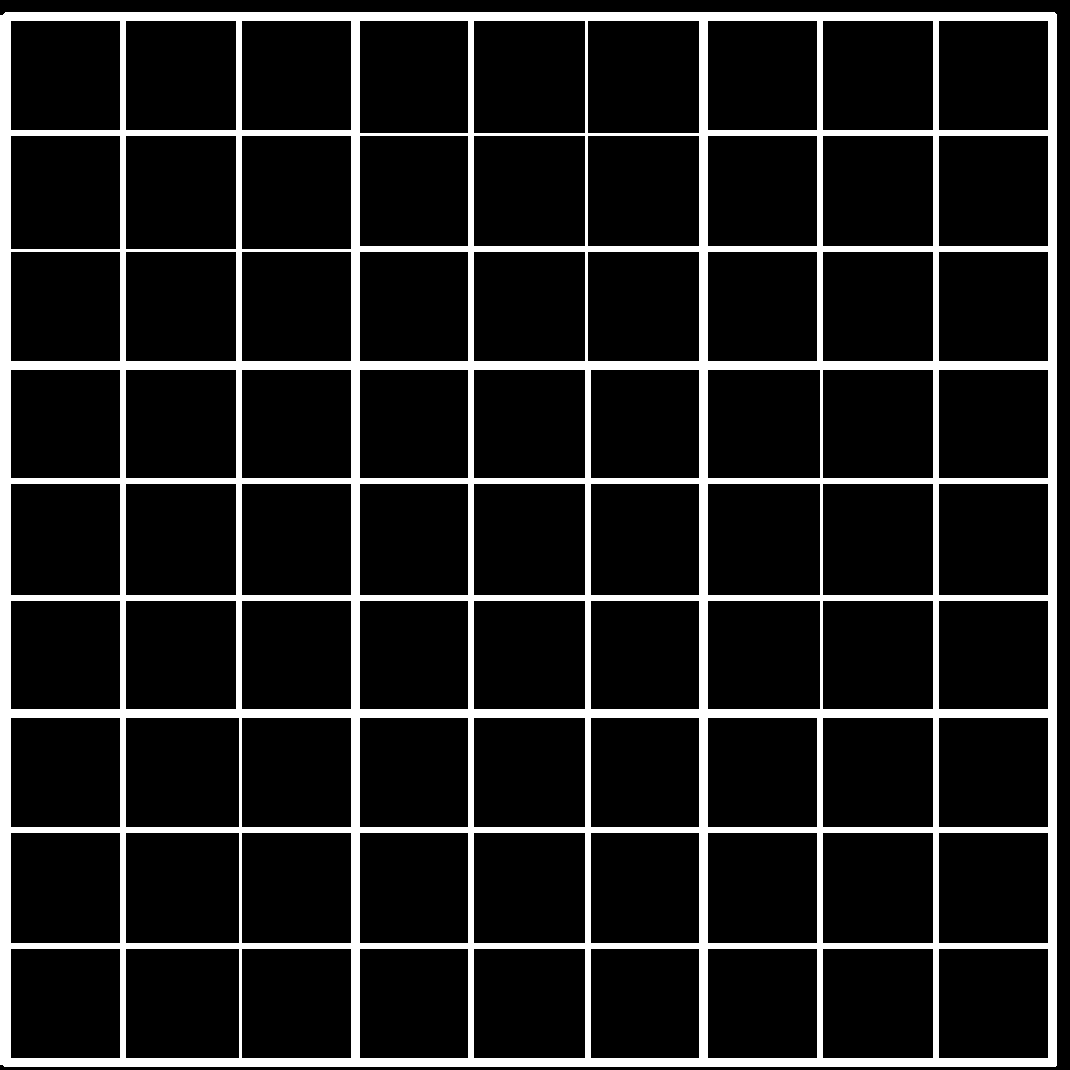

In [195]:
# 선 굵게 만들기
kernel = np.ones((3,3), np.uint8)

# 팽창 → 침식
morph = cv2.morphologyEx(line_img, cv2.MORPH_CLOSE, kernel, iterations=2)

# 결과 출력
cv2_imshow(morph)

In [196]:
# 세로/가로선 분류

vertical_lines = []
horizontal_lines = []

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        if abs(x1 - x2) < 10:
            vertical_lines.append((x1,y1,x2,y2))
        elif abs(y1 - y2) < 10:
            horizontal_lines.append((x1,y1,x2,y2))

print("세로 선:", vertical_lines)
print("가로 선:", horizontal_lines)

세로 선: [(np.int32(469), np.int32(1065), np.int32(469), np.int32(13)), (np.int32(358), np.int32(1065), np.int32(358), np.int32(13)), (np.int32(3), np.int32(1064), np.int32(3), np.int32(15)), (np.int32(586), np.int32(1065), np.int32(586), np.int32(13)), (np.int32(934), np.int32(1065), np.int32(934), np.int32(13)), (np.int32(1055), np.int32(1065), np.int32(1055), np.int32(14)), (np.int32(240), np.int32(1065), np.int32(240), np.int32(13)), (np.int32(124), np.int32(1065), np.int32(124), np.int32(13)), (np.int32(9), np.int32(1058), np.int32(9), np.int32(13)), (np.int32(472), np.int32(1059), np.int32(472), np.int32(13)), (np.int32(121), np.int32(1059), np.int32(121), np.int32(13)), (np.int32(821), np.int32(1059), np.int32(821), np.int32(13)), (np.int32(937), np.int32(1059), np.int32(937), np.int32(22)), (np.int32(700), np.int32(1059), np.int32(700), np.int32(20)), (np.int32(237), np.int32(706), np.int32(237), np.int32(373)), (np.int32(589), np.int32(708), np.int32(589), np.int32(372)), (np.int

In [197]:
# 중복 선 병합
def merge_lines(lines, axis='x', tol=10):
    coords = sorted(set([line[0] if axis=='x' else line[1] for line in lines]))
    filtered = []
    prev = None
    for c in coords:
        if prev is None or abs(c - prev) > tol:
            filtered.append(c)
            prev = c
    return filtered

merged_vertical = merge_lines(vertical_lines, axis='x', tol=10)
merged_horizontal = merge_lines(horizontal_lines, axis='y', tol=10)

print("병합된 세로 선:", merged_vertical)
print("병합된 가로 선:", merged_horizontal)

병합된 세로 선: [np.int32(3), np.int32(121), np.int32(237), np.int32(352), np.int32(469), np.int32(586), np.int32(700), np.int32(818), np.int32(934), np.int32(1049)]
병합된 가로 선: [np.int32(13), np.int32(131), np.int32(247), np.int32(362), np.int32(479), np.int32(596), np.int32(710), np.int32(828), np.int32(944), np.int32(1059)]


In [198]:
# 칸 개수 계산
cell_count = (len(merged_vertical)-1) * (len(merged_horizontal)-1)
print("칸 개수:", cell_count)

칸 개수: 81


격자선만 추출된 결과:


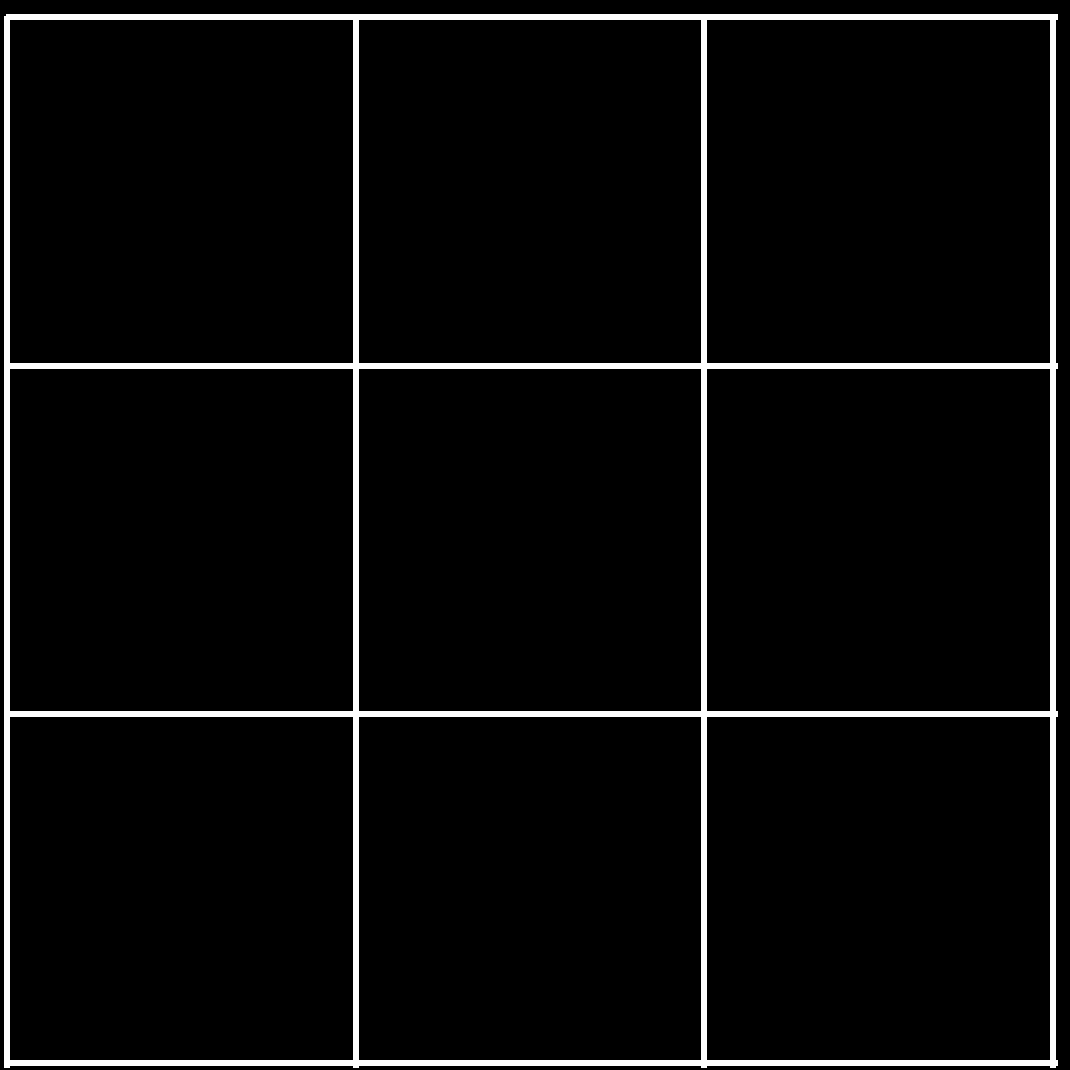

In [199]:
# 가로선 검출용 커널
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40,1))
detect_horizontal = cv2.morphologyEx(otsu_bin, cv2.MORPH_OPEN, horizontal_kernel, iterations=2)

# 세로선 검출용 커널
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,40))
detect_vertical = cv2.morphologyEx(otsu_bin, cv2.MORPH_OPEN, vertical_kernel, iterations=2)

grid = cv2.add(detect_horizontal, detect_vertical)
digits_only = cv2.subtract(otsu_bin, grid)

# 결과 확인
print("격자선만 추출된 결과:")
cv2_imshow(grid)

격자 제거 후 숫자만 남긴 결과:


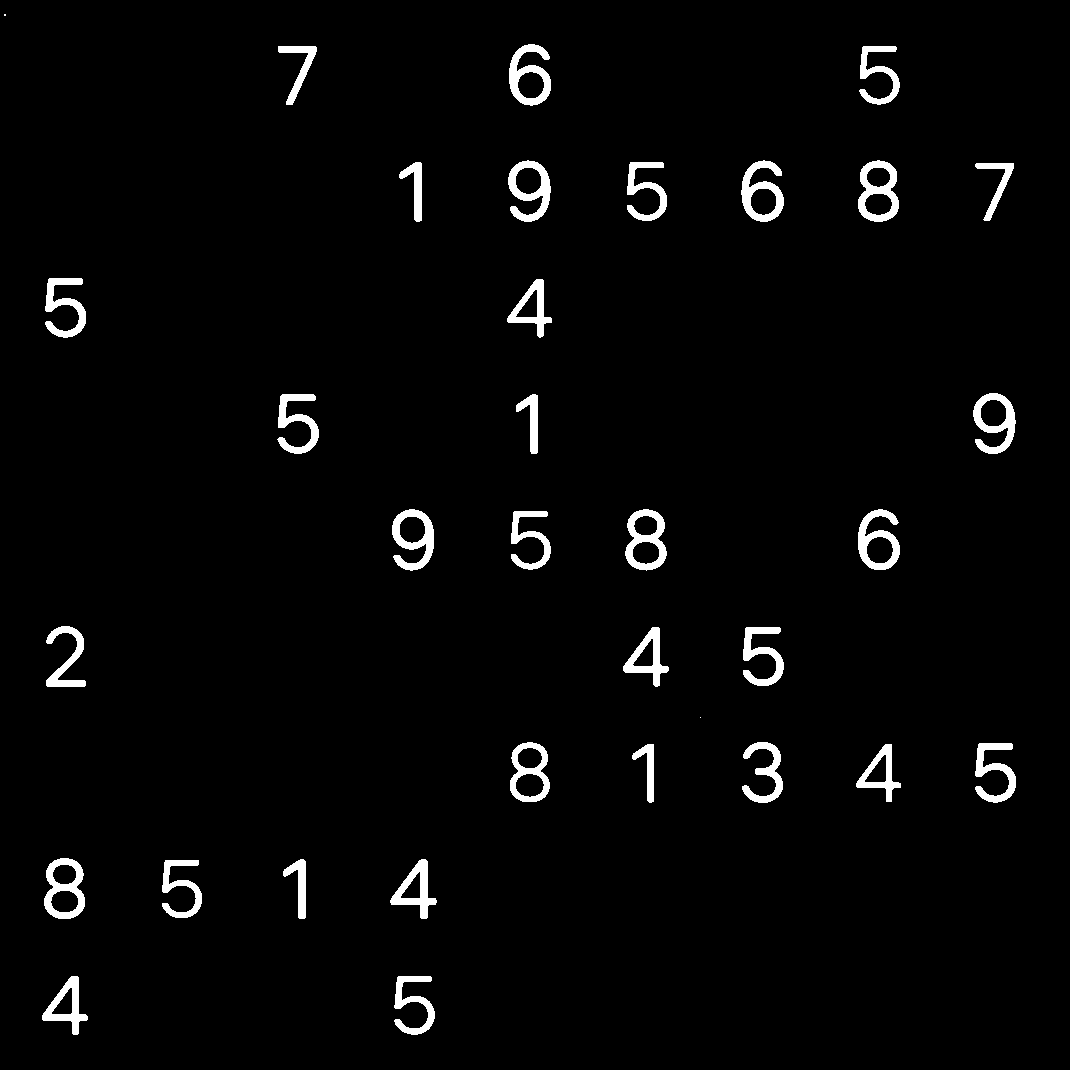

In [201]:
# 원본에서 격자선 제거 → 숫자만 남김
digits_only = cv2.subtract(otsu_bin, grid)

print("격자 제거 후 숫자만 남긴 결과:")
cv2_imshow(digits_only)

In [202]:
# 연결된 컴포넌트 찾기
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(digits_only, connectivity=8)

# 숫자 덩어리 필터링
min_area = 30
digit_count = 0
for i in range(1, num_labels):  # 0은 배경
    area = stats[i, cv2.CC_STAT_AREA]
    if area > min_area:
        digit_count += 1

# 전체 칸 개수
total_cells = 81
empty_cells = total_cells - digit_count

print("숫자가 들어있는 칸 개수:", digit_count)
print("빈 칸 개수:", empty_cells)

숫자가 들어있는 칸 개수: 32
빈 칸 개수: 49


총 숫자 덩어리 개수: 32


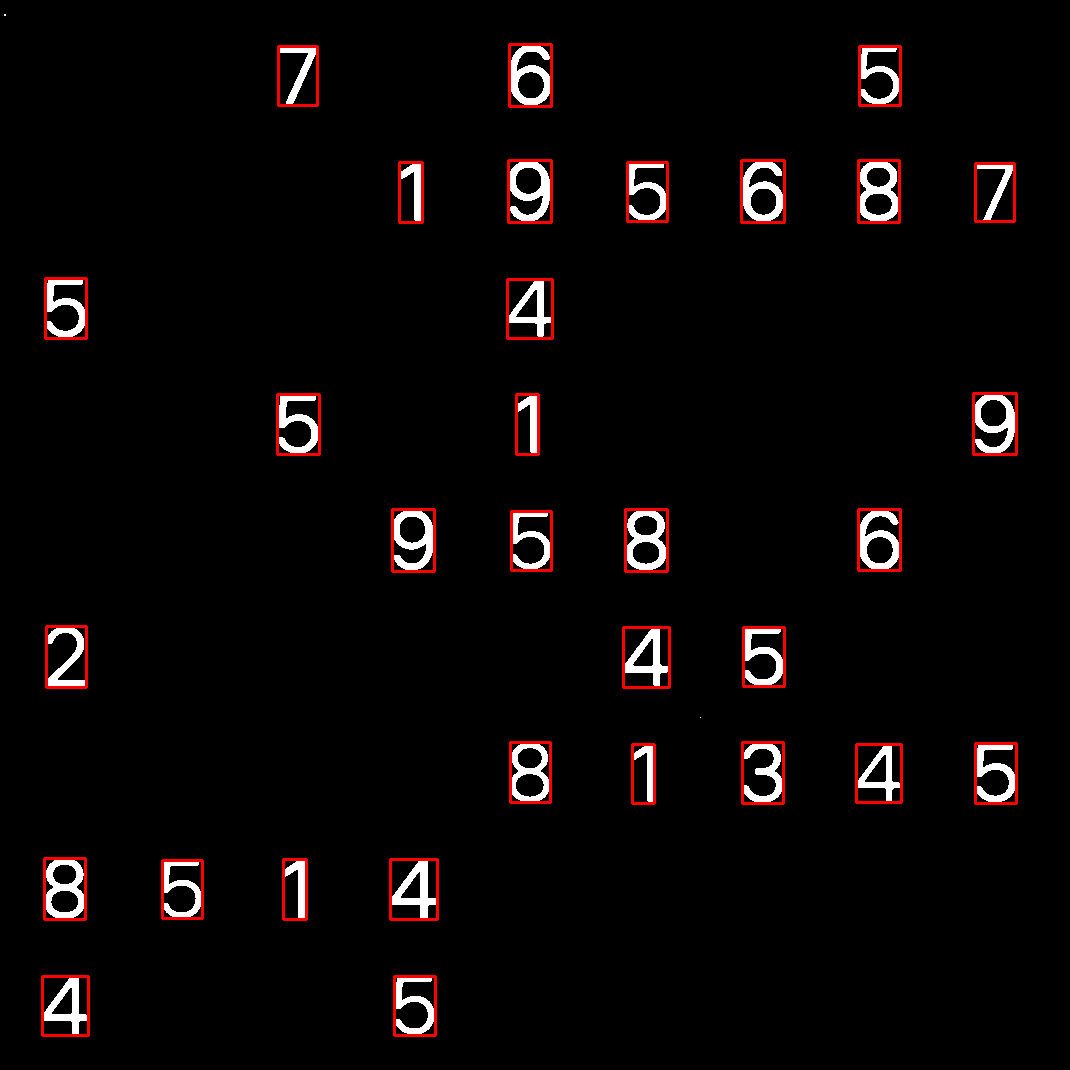

In [203]:
# 연결된 컴포넌트 찾기
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(digits_only, connectivity=8)

# 숫자 덩어리 필터링 및 표시
min_area = 30   # 너무 작은 잡음 제거
output = cv2.cvtColor(digits_only, cv2.COLOR_GRAY2BGR)  # 컬러로 변환해서 박스 표시

digit_rois = []  # 각 숫자 영역 저장

for i in range(1, num_labels):  # 0은 배경
    x, y, w, h, area = stats[i]
    if area > min_area:
        # 숫자 영역 잘라내기
        roi = digits_only[y:y+h, x:x+w]
        digit_rois.append(roi)

        # 숫자 영역에 박스 표시
        cv2.rectangle(output, (x, y), (x+w, y+h), (0, 0, 255), 2)

# 결과 출력
print("총 숫자 덩어리 개수:", len(digit_rois))
cv2_imshow(output)

숫자 1번 영역:


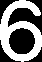

숫자 2번 영역:


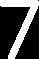

숫자 3번 영역:


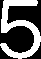

숫자 4번 영역:


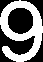

숫자 5번 영역:


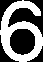

숫자 6번 영역:


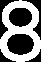

숫자 7번 영역:


숫자 8번 영역:


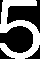

숫자 9번 영역:


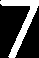

숫자 10번 영역:


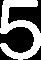

숫자 11번 영역:


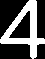

숫자 12번 영역:


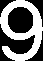

숫자 13번 영역:


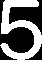

숫자 14번 영역:


숫자 15번 영역:


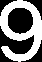

숫자 16번 영역:


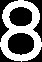

숫자 17번 영역:


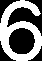

숫자 18번 영역:


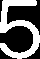

숫자 19번 영역:


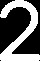

숫자 20번 영역:


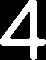

숫자 21번 영역:


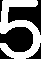

숫자 22번 영역:


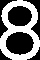

숫자 23번 영역:


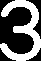

숫자 24번 영역:


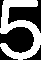

숫자 25번 영역:


숫자 26번 영역:


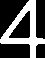

숫자 27번 영역:


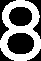

숫자 28번 영역:


숫자 29번 영역:


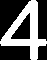

숫자 30번 영역:


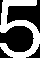

숫자 31번 영역:


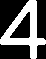

숫자 32번 영역:


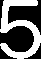

In [204]:
# 각 숫자 덩어리 개별 확인
for idx, roi in enumerate(digit_rois):
    print(f"숫자 {idx+1}번 영역:")
    cv2_imshow(roi)

In [205]:
# digit_rois 리스트가 준비되어 있다고 가정
pixel_counts = []

for idx, roi in enumerate(digit_rois):
    white_pixels = cv2.countNonZero(roi)
    pixel_counts.append((idx, white_pixels))

# 픽셀 개수 기준 정렬
pixel_counts.sort(key=lambda x: x[1])

# 그룹핑 파라미터
threshold = 30  # 픽셀 개수 차이가 이 값 이하이면 같은 그룹으로 묶음

groups = []
current_group = [pixel_counts[0]]

for i in range(1, len(pixel_counts)):
    prev = pixel_counts[i-1][1]
    curr = pixel_counts[i][1]

    if abs(curr - prev) <= threshold:
        current_group.append(pixel_counts[i])
    else:
        groups.append(current_group)
        current_group = [pixel_counts[i]]

groups.append(current_group)

# 결과 출력
for g_idx, group in enumerate(groups, 1):
    print(f"\n그룹 {g_idx}:")
    for idx, count in group:
        print(f" - {idx+1}번 ROI → 흰색 픽셀 {count}개")



그룹 1:
 - 25번 ROI → 흰색 픽셀 521개

그룹 2:
 - 14번 ROI → 흰색 픽셀 592개
 - 7번 ROI → 흰색 픽셀 595개
 - 28번 ROI → 흰색 픽셀 598개
 - 9번 ROI → 흰색 픽셀 611개

그룹 3:
 - 2번 ROI → 흰색 픽셀 683개

그룹 4:
 - 26번 ROI → 흰색 픽셀 833개

그룹 5:
 - 11번 ROI → 흰색 픽셀 890개

그룹 6:
 - 3번 ROI → 흰색 픽셀 931개
 - 19번 ROI → 흰색 픽셀 933개
 - 30번 ROI → 흰색 픽셀 934개
 - 18번 ROI → 흰색 픽셀 938개
 - 31번 ROI → 흰색 픽셀 957개
 - 8번 ROI → 흰색 픽셀 967개
 - 20번 ROI → 흰색 픽셀 968개
 - 32번 ROI → 흰색 픽셀 970개
 - 23번 ROI → 흰색 픽셀 988개

그룹 7:
 - 29번 ROI → 흰색 픽셀 1022개
 - 22번 ROI → 흰색 픽셀 1043개

그룹 8:
 - 24번 ROI → 흰색 픽셀 1076개
 - 10번 ROI → 흰색 픽셀 1078개
 - 21번 ROI → 흰색 픽셀 1079개
 - 13번 ROI → 흰색 픽셀 1080개

그룹 9:
 - 17번 ROI → 흰색 픽셀 1169개
 - 12번 ROI → 흰색 픽셀 1172개
 - 27번 ROI → 흰색 픽셀 1188개
 - 16번 ROI → 흰색 픽셀 1203개
 - 1번 ROI → 흰색 픽셀 1206개
 - 5번 ROI → 흰색 픽셀 1208개
 - 15번 ROI → 흰색 픽셀 1215개
 - 4번 ROI → 흰색 픽셀 1221개
 - 6번 ROI → 흰색 픽셀 1226개
